## Expected Credit Loss (ECL) Modeling for Retail Loans
## Notebook 3
## Preprocessing, PD Modeling

---


## Author: Will Wu

## Date: 2025-11-14
---

## **Table of Contents** ##

1. [Setup and Loading](#1)
2. [Data Preprocessing](#2)
    - [Filter Features](#2a)
    - [Outliers](#2b)
    - [Missing Values](#2c)
    - [Datetime columns](#2d)
3. [Feature Engineering](#3)
    - [Address State](#3a)
    - [Create Feature: is_revolve](#3b)
    - [Term](#3c)
    - [Home Ownership](#3d)
    - [Derogatory Public Records](#3e)
4. [Summary & Documentation](#4)
5. [Logistic Regression Baseline](#5)
6. [Logistic Regression: SMOTE](#6)
7. [Evaluation](#7)
8. [Logistic Regression: Training on Data from the Most Recent Year & SMOTE ](#8)
    - [Reselect Data](#8a)
    - [Train & Metrics ](#8b)
    - [Model comparisons](#8c)
    - [Model interpretation](#8d)
    - [Multicollinearity](#8e)
9. [Summary](#7)


---

## 1. Setup and Loading<a class="anchor" id="1"></a>

In [442]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import sys
import os

In [389]:
# Get the current directory of the notebook
current_directory = os.getcwd()
src_directory = os.path.join(current_directory, '../src')
sys.path.append(src_directory)

# Import the self_created class for model evaluation and downsampling
from model_evaluator import ModelEvaluator
from resampler import DownSampler

In [390]:
# Set Pandas option to display floats with 4 decimal places, preventing scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# Set the style
sns.set(style="whitegrid")

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [391]:
# Load the dataset
loan_df = pd.read_csv("../data/loan_clean.csv", index_col=0)

In [392]:
# Check the head
loan_df.head(3)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
1,7500,7500,36,13.7500,255.4300,E,E2,0,OWN,22000.0000,Not Verified,2007-06-01,Fully Paid,debt_consolidation,MA,14.2900,1.0000,0.0000,11.0000,7.0000,0.0000,4175,51.5000,8.0000,f,0.0000,9194.9800,7500.0000,1694.9800,0.0000,0.0000,0.0000,256.5900,0.0000,0.0000,0,0.0000,0.0000
2,6000,6000,36,10.5900,195.2800,C,C2,0,RENT,20000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,CT,12.9000,0.0000,4.0000,45.0000,5.0000,0.0000,13660,66.0000,6.0000,f,0.0000,7029.5300,6000.0000,1029.5300,0.0000,0.0000,0.0000,197.3600,0.0000,0.0000,0,0.0000,0.0000
3,4400,4400,36,9.6400,141.2500,B,B4,2,MORTGAGE,30000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,NJ,3.7200,0.0000,0.0000,0.0000,4.0000,0.0000,3493,63.5000,5.0000,f,0.0000,5084.4700,4400.0000,684.4700,0.0000,0.0000,0.0000,143.2800,0.0000,0.0000,0,0.0000,0.0000


In [393]:
# Check the shape
loan_df.shape

(232506, 38)

In [394]:
# Transform issue_d to datetime format
loan_df['issue_d'] = pd.to_datetime(loan_df['issue_d'])

---

## 2. Data Preprocessing <a class="anchor" id="2"></a>

### 2.1 Filter Features <a class="anchor" id="2a"></a>

Based on findings in EDA, we find some variables exhibit collinearity, and some features exhibit leaky information. I will filter out these predictors from our data set.

In [395]:
# Create a copy of loan_df
loan_pp_df = loan_df.copy()

# Check shape
loan_pp_df.shape

(232506, 38)

In [396]:
# Create a lost of features to be dropped 
drop_cols = [
    # Collinearity and multicollinearity
    'loan_amnt', 'installment', 'revol_bal', 'open_acc', 'sub_grade',

    # Leaky feature 
    'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries',  'collection_recovery_fee', 
    'last_pymnt_amnt', 'total_rec_late_fee', 'out_prncp', 'tot_cur_bal',

    # Irrelavant feature
    'emp_length'

]

In [397]:
# Drop 
loan_pp_df = loan_pp_df.drop(columns=drop_cols)

In [398]:
# Sanity check
loan_pp_df.shape

(232506, 23)

### 2.2 Outliers <a class="anchor" id="2b"></a>

Based on the findings from the EDA, I will address outliers before modeling. Since I plan to build GLM models like logistic regression, it is essential to handle outliers appropriately, as these models are significantly affected by outliers. Proper outlier management is crucial for achieving accurate and reliable model performance.

`annual_inc`

In [399]:
# Find the 99th percentile of annual income
percentile_99_inc = loan_pp_df['annual_inc'].quantile(0.99)
print(f"The 99th percentile of annual_inc is: {percentile_99_inc }")

The 99th percentile of annual_inc is: 238293.5500000036


In [400]:
# Replace outliers with the 99th percentile value
loan_pp_df.loc[loan_pp_df['annual_inc'] > percentile_99_inc , 'annual_inc'] = percentile_99_inc 

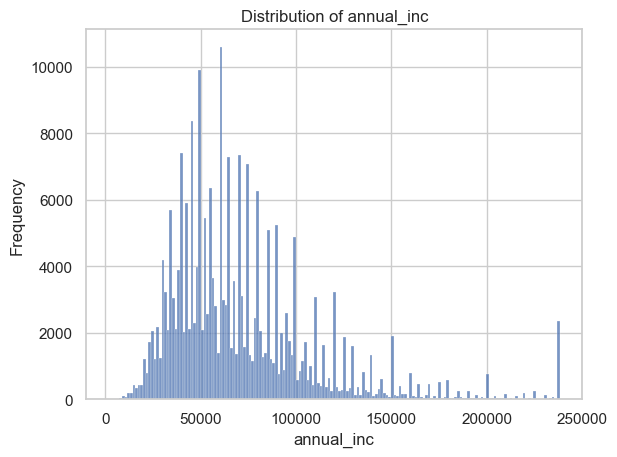

In [401]:
# Check distribution
sns.histplot(loan_pp_df['annual_inc'])
plt.title("Distribution of annual_inc")
plt.ylabel("Frequency")
plt.show()

`inq_last_6mths`

In [402]:
# Find the 99th percentile of inq_last_6mths
percentile_99_inq6 = loan_pp_df['inq_last_6mths'].quantile(0.99)
print(f"The 99th percentile of inq_last_6mths is: {percentile_99_inq6}")

The 99th percentile of inq_last_6mths is: 5.0


In [403]:
# Replace outliers with the 99th percentile value
loan_pp_df.loc[loan_pp_df['inq_last_6mths'] > percentile_99_inq6 , 'inq_last_6mths'] = percentile_99_inq6 

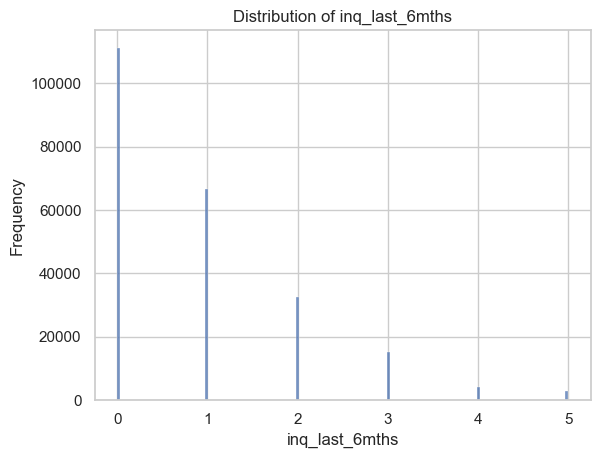

In [404]:
# Check distribution
sns.histplot(loan_pp_df['inq_last_6mths'])
plt.title("Distribution of inq_last_6mths")
plt.ylabel("Frequency")
plt.show()

`revol_util`

In [405]:
# Identify susicious outliers 
util_outliers = loan_pp_df[loan_pp_df['revol_util'] >= 150]

util_outliers 

,funded_amnt,term,int_rate,grade,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,pub_rec,revol_util,total_acc,initial_list_status,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
262302,35000,36,25.8300,G,RENT,165800.0000,Verified,2014-03-01,Fully Paid,debt_consolidation,MA,7.4200,0.0000,0.0000,NaN,0.0000,153.0000,5.0000,f,10800.0000,0,0.0000,0.0000
278667,3500,36,12.4900,B,RENT,45000.0000,Verified,2014-04-01,Fully Paid,debt_consolidation,CA,14.6700,0.0000,0.0000,67.0000,0.0000,892.3000,9.0000,f,300.0000,0,0.0000,0.0000
278809,10000,36,14.1600,C,OWN,91000.0000,Not Verified,2014-04-01,Fully Paid,debt_consolidation,CA,20.9400,0.0000,0.0000,30.0000,0.0000,150.7000,37.0000,f,6200.0000,0,0.0000,0.0000
317285,16500,60,14.4900,C,MORTGAGE,48000.0000,Source Verified,2014-06-01,In Grace Period,debt_consolidation,NC,9.3300,0.0000,0.0000,NaN,0.0000,366.6000,15.0000,f,700.0000,0,0.0000,0.0000


As mentioned earlier in EDA, such utilizaiton ratio (above 150% of credit allowance) seems invalid. Due to there are only 4 records and we have a relatively large dataset, I will remove these four observations.

In [406]:
# Drop outliers
loan_pp_df = loan_pp_df[loan_pp_df['revol_util'] < 150]

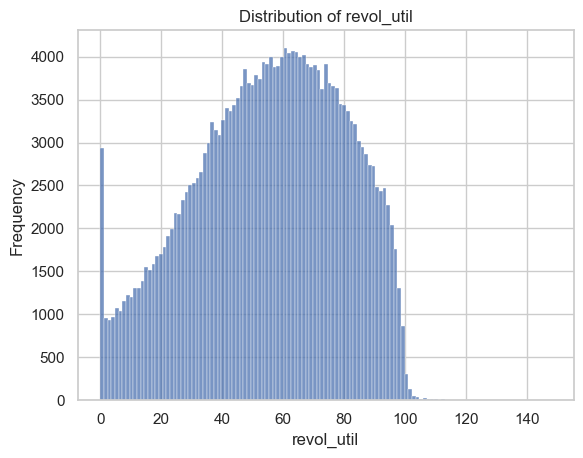

In [407]:
# Check distribution
sns.histplot(loan_pp_df['revol_util'])
plt.title("Distribution of revol_util")
plt.ylabel("Frequency")
plt.show()

`total_acc`

In [408]:
# Find the 99.9th percentile of total_acc
percentile_999_total_acc = loan_pp_df['total_acc'].quantile(0.999)
print(f"The 99.9th percentile of total_acc is: {percentile_999_total_acc}")

The 99.9th percentile of total_acc is: 69.0


In [409]:
# Replace outliers with the 99th percentile value
loan_pp_df.loc[loan_pp_df['total_acc'] > percentile_999_total_acc , 'total_acc'] = percentile_999_total_acc

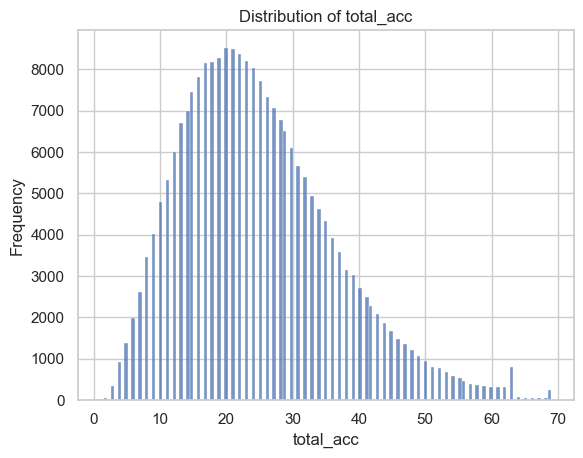

In [410]:
# Check distribution
sns.histplot(loan_pp_df['total_acc'])
plt.title("Distribution of total_acc")
plt.ylabel("Frequency")
plt.show()

### 2.3 Missing Values <a class="anchor" id="2c"></a>

In the EDA, I found that observations with missing values in `mths_since_last_delinq` are very similar to those with high values in the months since the last delinquency. This indicates that the missing values are likely due to borrowers having no history of delinquencies. Therefore, I will create segments in this variables, first to bin existing values into bins with similar characteristics, then replace missing values with tag like No History.

In [411]:
# Define the function to categorize months since last delinquency
def categorize_delinq_months(months):

    # 1. Handle NaN (Missing/No Delinquency Ever)
    if pd.isna(months):
        return 'Missing History'

    # 2. Categorization logic for valid numeric months
    elif months <= 12:
        return 'in 1Yr'
    elif months <= 24:
        return 'in 2Yrs'
    else:  
        return 'More than 2Yrs'

# Apply the function to create the new delinquency months category column
loan_pp_df['mths_since_delinq_category'] = loan_pp_df['mths_since_last_delinq'].apply(categorize_delinq_months)

In [412]:
# Drop orignial column
loan_pp_df = loan_pp_df.drop(columns='mths_since_last_delinq')

In [413]:
# Check
loan_pp_df['mths_since_delinq_category'].value_counts()

mths_since_delinq_category
Missing History    129581
More than 2Yrs      63096
in 2Yrs             21070
in 1Yr              18755
Name: count, dtype: int64

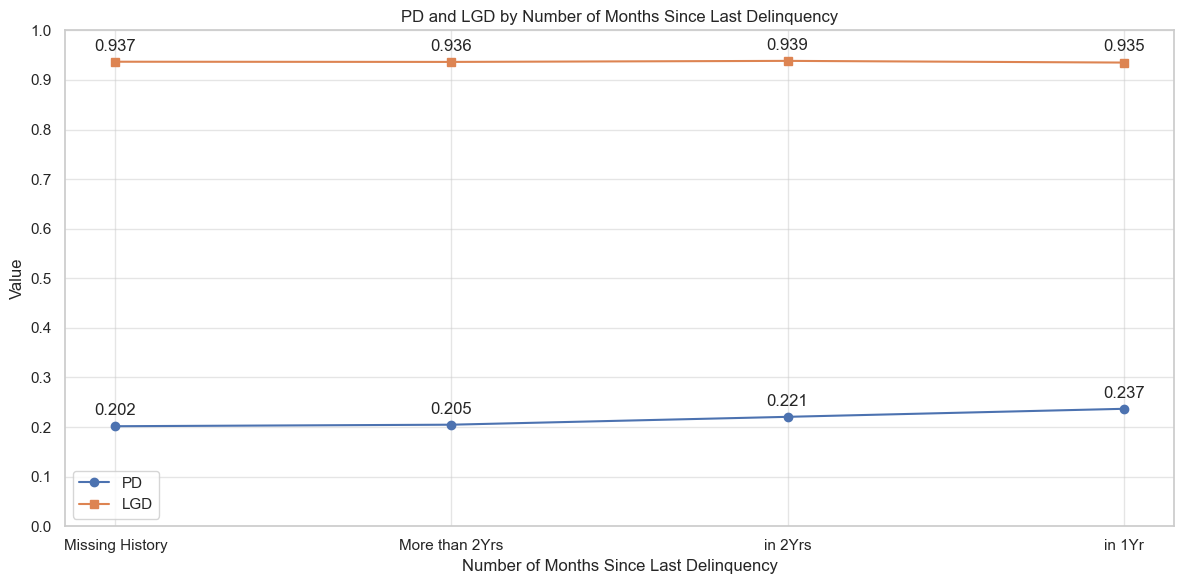

In [414]:
# Calculate PD and LGD by mths_since_delinq_category
pd_by_mths_since_delinq_category = loan_pp_df.groupby('mths_since_delinq_category')['is_default'].mean()
default_loans = loan_pp_df[loan_pp_df['is_default'] == 1]
avg_lgd_by_mths_since_delinq_category = default_loans.groupby('mths_since_delinq_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_mths_since_delinq_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_mths_since_delinq_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Number of Months Since Last Delinquency')
plt.ylabel('Value')
plt.title('PD and LGD by Number of Months Since Last Delinquency')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### 2.4 Datetime columns <a class="anchor" id="2d"></a>

Currently the `issue_d` column is in datatime format, I will decompose it into year and month columns.

In [415]:
# Extract issue year and issue month
loan_pp_df['issue_year'] = loan_pp_df['issue_d'].dt.year
loan_pp_df['issue_month'] = loan_pp_df['issue_d'].dt.month

In [416]:
# Drop the original issue_d column
loan_pp_df = loan_pp_df.drop(columns='issue_d')

In [417]:
# Sanity check
loan_pp_df.shape

(232502, 24)

---

## 3. Feature Engineering <a class="anchor" id="2"></a>

### 3.1 Address State <a class="anchor" id="3a"></a>

Accoring to the findings in EDA, I will bin states into groups that share similar PD, this helps reduce dimension and prevent overfitting.

In [418]:
def segment_states(state):
    if state in ['ME', 'ID', 'DC', 'WY']:
        return "State Group 1"  # Group 1: PD < 15%
    elif state in ['NH', 'CO', 'AK']:
        return "State Group 2"   # Group 2: PD 15% - 17.5%
    elif state in ['WV', 'MT', 'CT', 'SC', 'KS', 'OR', 'TX', 'WA', 'IL', 'VT', 'UT', 'CA', 'MA']:
        return "State Group 3"   # Group 3: PD 17.5% - 20%
    elif state in ['WI', 'GA', 'AZ', 'SD', 'MN', 'VA', 'RI', 'MD', 'DE', 'PA', 'OH', 'NJ', 'MO', 'NC', 'MI', 'LA', 'NY', 'KY']:
        return "State Group 4"   # Group 4: PD 20% - 22.5%
    elif state in ['AR', 'NM', 'OK', 'HI', 'IA', 'FL', 'AL', 'NV']:
        return "State Group 5"   # Group 5: PD 22.5% - 25%
    elif state in ['IN', 'TN', 'MS', 'NE']:
        return "State Group 6"   # Group 6: PD > 25%


In [419]:
# Apply the segmentation function to create a new column for PD groups
loan_pp_df['state_group'] = loan_pp_df['addr_state'].apply(segment_states)

In [420]:
# Sanity Check
loan_pp_df['state_group'].value_counts()

state_group
State Group 4    98951
State Group 3    92037
State Group 5    28461
State Group 2     6752
State Group 6     4965
State Group 1     1336
Name: count, dtype: int64

In [421]:
# Drop original state_group column
loan_pp_df = loan_pp_df.drop(columns='addr_state')

In [422]:
# Sanity check
loan_pp_df.shape

(232502, 24)

### 3.2 Create Feature: is_revolve <a class="anchor" id="3b"></a>

The `total_rev_hi_lim` represents the total revolving credit high limit. However, our analysis indicates that an informative feature in revolving accounts is the revolving account utilization rate found in the column `revol_util`. 

Here, I plan to use `total_rev_hi_lim` to create a dummy variable that indicates whether a loan is a revolving loan. This binary indicator will be more useful for the model than the actual numeric values of the credit limit. Additionally, any outliers in `total_rev_hi_lim` can be addressed simultaneously, as this column will be dropped after creating the dummy variable.

In [423]:
# Create a new variable
loan_pp_df['is_revl_acct'] = np.where(loan_pp_df['total_rev_hi_lim'] > 0, 1, 0) 

In [424]:
# Sanity check
loan_pp_df['is_revl_acct'].value_counts()

is_revl_acct
1    167895
0     64607
Name: count, dtype: int64

In [425]:
# Drop the original col
loan_pp_df = loan_pp_df.drop(columns='total_rev_hi_lim')

In [426]:
# Sanity check
loan_pp_df.shape

(232502, 24)

### 3.3 Term <a class="anchor" id="3c"></a>

In [427]:
# Check value counts
loan_pp_df['term'].value_counts()

term
36    180247
60     52255
Name: count, dtype: int64

Since our `term` column only contains two distinct values, converting them into dummy variables will optimize model training and simplify coefficient interpretation. Although the term of 60 months is larger than 36 months, treating this column as a continuous numeric variable implies a linear, step-by-step increase in risk as the term increases. This assumption may not hold true in our dataset, making the use of dummy variables a more appropriate approach.

In [428]:
# Create dummy column
# Since it only has binary values, I will create one variable only
loan_pp_df['is_term_60_mths'] = np.where(loan_pp_df['term'] == 60, 1, 0)

# Sanity check
loan_pp_df['is_term_60_mths'].value_counts()

is_term_60_mths
0    180247
1     52255
Name: count, dtype: int64

In [429]:
# Drop the original column
loan_pp_df = loan_pp_df.drop(columns='term')

### 3.4 Home Ownership <a class="anchor" id="3d"></a>

In [430]:
# Check value counts
loan_pp_df['home_ownership'].value_counts()

home_ownership
MORTGAGE    114445
RENT         99007
OWN          18832
OTHER          174
NONE            43
ANY              1
Name: count, dtype: int64

The counts of values in "NONE," "ANY," and "OTHER" are all relatively low and not easy to interpret. Therefore, I will consolidate these three values into a single category to simplify the analysis and enhance interpretability.

In [431]:
# Consolidate the values 'NONE', 'ANY', and 'OTHER' into a single category 'other_none_any'
loan_pp_df['home_ownership'] = loan_pp_df['home_ownership']\
    .replace({'NONE': 'Other_none_any', 'ANY': 'Other_none_any', 'OTHER': 'Other_none_any'})

In [432]:
# Sanity check
loan_pp_df['home_ownership'].value_counts()

home_ownership
MORTGAGE          114445
RENT               99007
OWN                18832
Other_none_any       218
Name: count, dtype: int64

### 3.5 Derogatory Public Records <a class="anchor" id="3e"></a>

In [433]:
# Check value counts
loan_pp_df['pub_rec'].value_counts()

pub_rec
0.0000     206338
1.0000      23259
2.0000       2062
3.0000        527
4.0000        167
5.0000         78
6.0000         39
7.0000         15
8.0000          6
9.0000          6
10.0000         5
Name: count, dtype: int64

The distribution of `pub_rec` exhibits skewness. Accoding to the analysis from EDA, PD increases when number of derogatory public records increases. I will reexamine the PD LGD across 10 values to determine the optimal way to segment this feature.

In [434]:
# Calculate PD and LGD by pub_rec
loan_pp_df_pub_rec = loan_pp_df.groupby('pub_rec')['is_default'].mean().reset_index()
default_loans_pub_rec = loan_pp_df[loan_pp_df['is_default'] == 1]
avg_lgd_by_pub_rec = default_loans_pub_rec.groupby('pub_rec')['loss_given_default'].mean().reset_index()

# Rename columns for clarity
loan_pp_df_pub_rec.columns = ['pub_rec', 'PD']
avg_lgd_by_pub_rec.columns = ['pub_rec', 'LGD']

# Merge the two DataFrames on pub_rec
pd_lgd_by_pub_rec = pd.merge(loan_pp_df_pub_rec, avg_lgd_by_pub_rec, on='pub_rec')

# Add value counts column
pd_lgd_by_pub_rec["Value_Counts"] = loan_pp_df['pub_rec'].value_counts()

pd_lgd_by_pub_rec

,pub_rec,PD,LGD,Value_Counts
0,0.0000,0.2055,0.9353,206338
1,1.0000,0.2167,0.9476,23259
2,2.0000,0.2381,0.9447,2062
3,3.0000,0.2277,0.9470,527
4,4.0000,0.2275,0.9408,167
5,5.0000,0.3077,0.9668,78
6,6.0000,0.2564,0.9008,39
7,7.0000,0.3333,0.8902,15
8,8.0000,0.1667,1.0000,6
9,9.0000,0.5000,1.0000,6


In [435]:
def categorize_pub_rec(count):

    if count == 0:
        return '0 record'
    elif count == 1:
        return '1 record'
    elif count == 2:
        return '2 records'
    else:  # count >= 3
        return '3+ records'

# Apply the function to create the new public records category column
loan_pp_df['derogatory_pub_rec'] = loan_pp_df['pub_rec'].apply(categorize_pub_rec)

In [436]:
# Sanity check
loan_pp_df['derogatory_pub_rec'].value_counts()

derogatory_pub_rec
0 record      206338
1 record       23259
2 records       2062
3+ records       843
Name: count, dtype: int64

In [437]:
# Drop the original column
loan_pp_df = loan_pp_df.drop(columns='pub_rec')

In [438]:
# Sanity check
loan_pp_df.shape

(232502, 24)

---

## 4. Summary & Documentation <a class="anchor" id="4"></a>


| **Feature**                          | **Operation**                                          |
|--------------------------------------|-------------------------------------------------------|
| `loan_amnt`                         | Drop due to collinearity     |
| `installment`                        | Drop due to collinearity     |
| `open_acc`                          | Drop due to collinearity     |
| `sub_grade`                              | Drop and keep `grade`                        |
| `revol_bal`                         | Drop due to multicolliearity                       |
| `total_rec_prncp`                   | Drop due to information leakage                              |
| `tot_cur_bal`                       | Drop due to information leakage   |
| `total_pymnt`                       | Drop due to information leakage                       |
| `total_rec_int`                     | Drop due to information leakage                       |
| `recoveries`                         | Drop due to information leakage                       |
| `collection_recovery_fee`           | Drop due to information leakage                       |
| `last_pymnt_amnt`                   | Drop due to information leakage                       |
| `total_rec_late_fee`                | Drop due to information leakage                       |
| `out_prncp`                         | Drop due to information leakage                       |
| `emp_length`                         | Drop due to irrelavant information                      |
| `annual_inc`                         | Outliers replaced by 99th percentile value             |
| `inq_last_6mths`                         | Outliers replaced by 99th percentile value               |
| `revol_util`                         | Outliers with values > 150 has been dropped.             |
| `total_acc`                         | Outliers replaced by 99.9th percentile value            |
| `issue_d`                         | Datetime column has been separated into `issue_year`, `issue_month` columns          |
| `mths_since_last_delinq`              | Missing values replaced by "Missing History", other values heve been segmented. Create new variable:  `mths_since_delinq_category`       |
| `addr_state`              | States has been aggregated into groups with similar PD. New variable (`state_group`)       |
| `total_rev_hi_lim`              | Create new variable to flag if this is a revolving loan. New variable `is_revolve`: 0 if  `total_rev_hi_lim`  == 0 otherwise 1      |
| `term`                         | Replaced by dummy variable `is_term_60_mths`          |
| `home_ownership`                         | Consolidate three values (OTHER, NONE, ANY) with few observations           |
| `pub_rec`                         | Segment data into categories with shared PD characteristics. New variable: `derogatory_pub_rec`           |




---

## 5. Train Test Split <a class="anchor" id="5"></a>

As mentioned in last notebook, we should use time-based split to avoid leakage and ensure a realistic test.

In [380]:
# Create a copy of df
pd_model_df = loan_pp_df.copy()

In [381]:
# Check number of observations each yeat
pd_model_df['issue_year'].value_counts()

issue_year
2014    73459
2013    71575
2012    48027
2011    19067
2010    12157
2009     5265
2008     2381
2007      571
Name: count, dtype: int64

In [382]:
# Define the cutoff year
cutoff_year = 2014

# Create the training set (2007-2013)
train_df = pd_model_df[pd_model_df['issue_year'] < cutoff_year].copy()

# Create the test set (2014)
test_df = pd_model_df[pd_model_df['issue_year'] >= cutoff_year].copy()

print(f"Training set size: {len(train_df)}, \
    proportions: {train_df.shape[0] / (test_df.shape[0] + train_df.shape[0]):.1%},\
        PD: {train_df['is_default'].mean():.3f}")

print(f"Testing set size: {len(test_df)}, \
    proportions: {test_df.shape[0] / (test_df.shape[0] + train_df.shape[0]):.1%} \
         PD: {test_df['is_default'].mean():.3f}")

Training set size: 159043,     proportions: 68.4%,        PD: 0.188
Testing set size: 73459,     proportions: 31.6%          PD: 0.247


In [383]:
# Define the list of columns to exclude
cols_to_drop = ['is_default', 'exposure_at_default', 'loss_given_default', 'loan_status'] 

# Create X_train X_test
X_train = train_df.drop(columns=cols_to_drop).copy()
X_test = test_df.drop(columns=cols_to_drop).copy()

In [384]:
# Create y
y_train = train_df['is_default'].copy()
y_test = test_df['is_default'].copy()

In [385]:
# Check:
print(f"X_train shape: {X_train.shape}, y_train shape {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape {y_test.shape}")

X_train shape: (159043, 20), y_train shape (159043,)
X_test shape: (73459, 20), y_test shape (73459,)


In [440]:
# Find categorical columns in X_train
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = X_train.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
ordinal_columns = ['grade'] 

# Remove 'grade' and 'sub_grade' from categorical columns
categorical_columns = [col for col in categorical_columns if col not in ['grade']]

# Sanity check
print(f"Number of cols in total: {len(categorical_columns) + len(numerical_columns) + len(ordinal_columns)}")

Number of cols in total: 20


---

## 5. Logistic Regression: Baseline <a class="anchor" id="5"></a>

In [443]:
# Define the preprocessing pipeline for ordinal columns
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder()),
    ('scaler', StandardScaler())
])

# Create a column transformer
preprocessor = ColumnTransformer(  
    transformers=[
        ('cat_cols', OneHotEncoder(sparse_output=False,
                                   handle_unknown='ignore',
                                   drop='first'), categorical_columns), 
        ('num_cols', StandardScaler(), numerical_columns),
        ('ord_cols', ordinal_pipeline, ordinal_columns)       
    ]
)

In [444]:
# Create the pipeline using logistic regression
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression())
])

In [445]:
# Fit the model
pipeline_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose',
                                                   'initial_list_status',
                                                   'mths_since_delinq_category',
                                                   'state_group',
                                                   'derogatory_pub_rec']),
                                                 ('num_cols', StandardScaler(),
                                                  ['funded_amnt', 'int_rate',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'revol_util', 'total_acc',
                                                   'issue_year', 'issue_month',
                                                   'is_revl_acct',
                                                   'is_term_60_mths']),
                                                 ('ord_cols',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['grade'])])),
                ('logreg', LogisticRegression())])

Create a function to store model outputs

In [446]:
# Function to fit a model and store its metrics
def evaluate_model(pipeline, X_train, y_train, X_test, y_test, model_name):
    global metrics_summary_df  # Allow access to the global DataFrame
    
    # Fit the pipeline
    pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_test = pipeline.predict(X_test)
    y_pred_proba_test = pipeline.predict_proba(X_test)[:, 1]  # Get predicted probabilities for ROC AUC

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_pred_proba_test)

    # Create a temporary DataFrame with the results
    new_metrics = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [accuracy],
        'Recall': [recall],
        'Precision': [precision],
        'F1 Score': [f1],
        'AUC': [auc]
    })

    # Concatenate the new metrics with the existing DataFrame
    metrics_summary_df = pd.concat([metrics_summary_df, new_metrics], ignore_index=True)
    return metrics_summary_df  # Return the updated DataFrame



Evaluation: Logistic Regression Baseline
Confusion matrices: 


<Figure size 300x300 with 0 Axes>

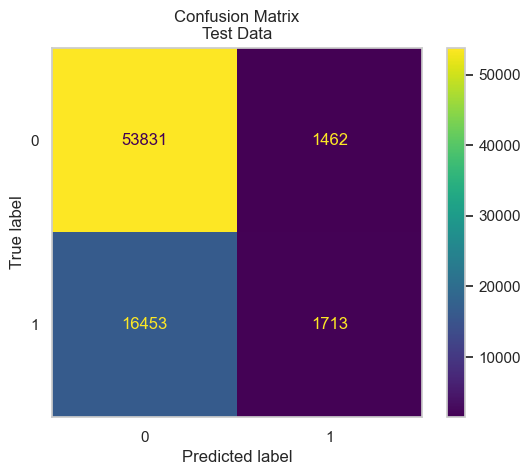

Test Data Classification Report: 
==================================================================               precision    recall  f1-score   support

           0       0.77      0.97      0.86     55293
           1       0.54      0.09      0.16     18166

    accuracy                           0.76     73459
   macro avg       0.65      0.53      0.51     73459
weighted avg       0.71      0.76      0.69     73459

Recall Score:
Train: 0.059
Test: 0.094 
False Positive Rate:
Train: 0.013
Test: 0.026 
AUC Score:
Train: 0.702
Test: 0.690 
Accuracy Score:
Train: 0.812
Test: 0.756 
Precision Score:
Train: 0.510
Test: 0.540 
F1 Score:
Train: 0.107
Test: 0.161 


In [447]:
# Use self-built ModelEvaluator to evaluate the mode
print("Evaluation: Logistic Regression Baseline")
evaluator = ModelEvaluator(pipeline_base)
evaluator.evaluate(X_train, X_test, y_train, y_test)

ROC Curve: Logistic Regression (Baseline)


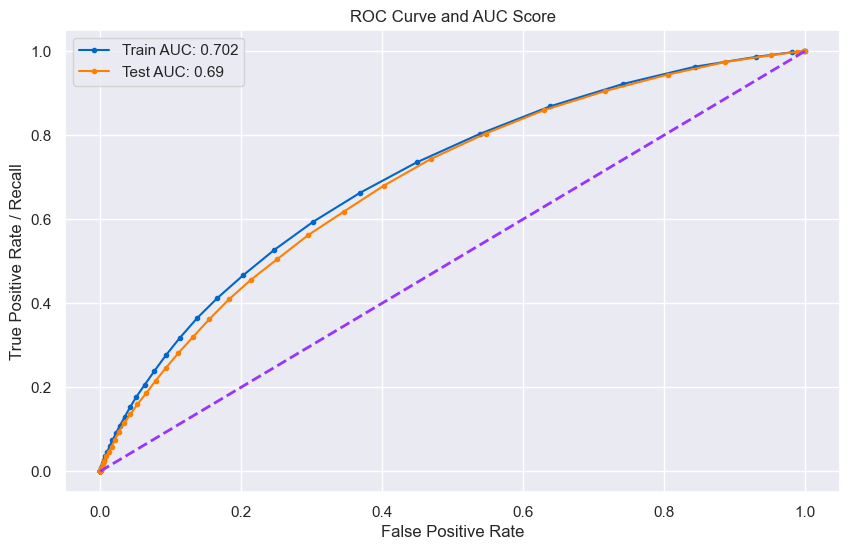

In [448]:
# Plot the roc curve 
print('======='*8)
print('ROC Curve: Logistic Regression (Baseline)')
print('======='*8)
evaluator.plot_roc_auc_curve(X_train, X_test, y_train, y_test)

In [449]:
# Initialize an empty DataFrame to store metrics for different models
metrics_summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Recall', 'Precision', 'F1 Score', 'AUC'])

In [450]:
# Store the metrics of Logistic Regression 
metrics_summary_df = evaluate_model(pipeline_base, X_train, y_train, X_test, y_test, 'Logistic Regression Baseline')
metrics_summary_df

,Model,Accuracy,Recall,Precision,F1 Score,AUC
0,Logistic Regression Baseline,0.7561,0.0943,0.5395,0.1605,0.6896


- **Insights**:

1. **Indications of Overfitting**: There is evidence of overfitting, as the accuracy of the training data (0.813)  exceeds that of the test data (0.756).

2. **AUC Interpretation**: The AUC value of approximately 0.7 indicates that the model possesses a moderate level of discriminatory ability in distinguishing between the positive and negative classes.

3. **Recall Score Analysis**: The model's recall score is relatively poor, reflecting its weakness in identifying true defaults among all defaulting borrowers.


---

## 6. Logistic Regression: SMOTE <a class="anchor" id="6"></a>

Our dataset exhibits class imbalance, with default instances comprising approximately 20% of the total data. This imbalance likely accounts for the relatively low recall score of our model, indicating its inefficacy in accurately predicting true defaults. 

To improve the model's performance, particularly in its ability to identify default cases, I will employ resampling techniques while maintaining the Logistic Regression model. The objective is to enhance the model's predictive accuracy on defaults. 

Through these resampling strategies, I will reassess the model's performance and examine whether predictions have improved.

In [451]:
pipeline_smote = ImbPipeline(steps=[
    # Step 1: Preprocessing (OHE + Scaling)
    ('preprocessor', preprocessor), 
    
    # Step 2: Resampling 
    ('smote', SMOTE(random_state=42)), 
    
    # Step 3: Classification
    ('classifier', LogisticRegression())
])

# Fit the model
pipeline_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose',
                                                   'initial_list_status',
                                                   'mths_since_delinq_category',
                                                   'state_group',
                                                   'derogatory_pub_rec']),
                                                 ('num_cols', StandardScaler(),
                                                  ['funded_amnt', 'int_rate',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'revol_util', 'total_acc',
                                                   'issue_year', 'issue_month',
                                                   'is_revl_acct',
                                                   'is_term_60_mths']),
                                                 ('ord_cols',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['grade'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', LogisticRegression())])

Evaluation: Logistic Regression with SMOTE
Confusion matrices: 


<Figure size 300x300 with 0 Axes>

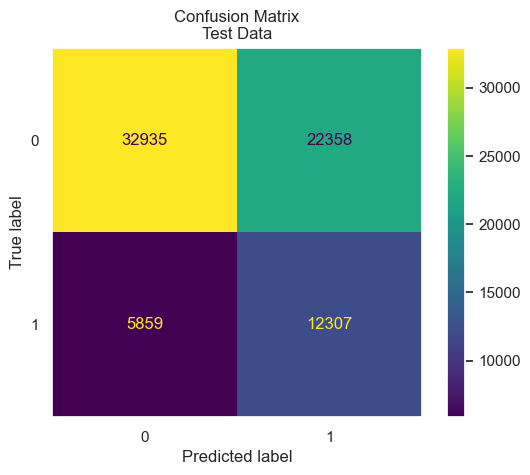

Test Data Classification Report: 
==================================================================               precision    recall  f1-score   support

           0       0.85      0.60      0.70     55293
           1       0.36      0.68      0.47     18166

    accuracy                           0.62     73459
   macro avg       0.60      0.64      0.58     73459
weighted avg       0.73      0.62      0.64     73459

Recall Score:
Train: 0.631
Test: 0.677 
False Positive Rate:
Train: 0.344
Test: 0.404 
AUC Score:
Train: 0.698
Test: 0.687 
Accuracy Score:
Train: 0.652
Test: 0.616 
Precision Score:
Train: 0.299
Test: 0.355 
F1 Score:
Train: 0.406
Test: 0.466 


In [452]:
# Use self-built ModelEvaluator to evaluate the mode
print("Evaluation: Logistic Regression with SMOTE")
evaluator = ModelEvaluator(pipeline_smote)
evaluator.evaluate(X_train, X_test, y_train, y_test)

ROC Curve: Logistic Regression (With SMOTE)


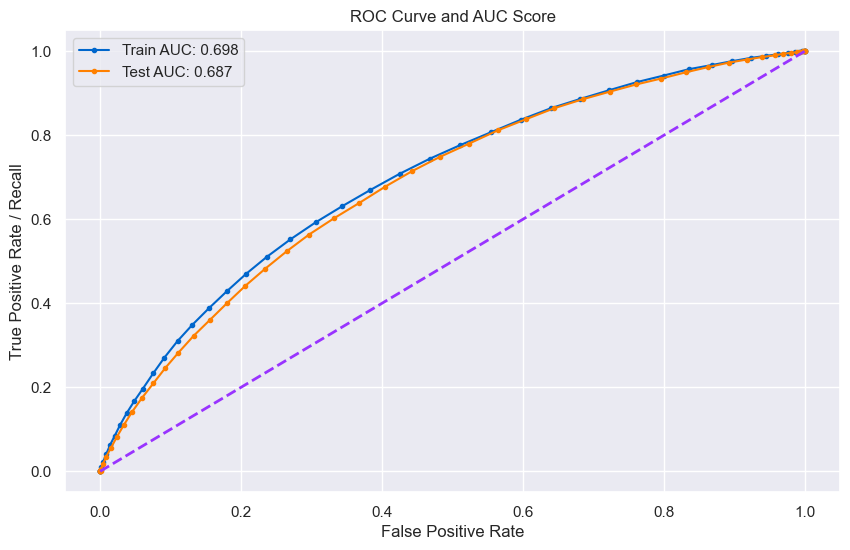

In [453]:
# Plot the roc curve 
print('======='*8)
print('ROC Curve: Logistic Regression (With SMOTE)')
print('======='*8)
evaluator.plot_roc_auc_curve(X_train, X_test, y_train, y_test)

In [454]:
# Store the metrics of Logistic Regression 
metrics_summary_df = evaluate_model(pipeline_smote, X_train, y_train, X_test, y_test, 'Logistic Regression SMOTE')
metrics_summary_df

,Model,Accuracy,Recall,Precision,F1 Score,AUC
0,Logistic Regression Baseline,0.7561,0.0943,0.5395,0.1605,0.6896
1,Logistic Regression SMOTE,0.6159,0.6775,0.3550,0.4659,0.6866


- **Insights:**

1. **Indications of Overfitting**: The model shows evidence of overfitting, as the accuracy of the training data (0.652) exceeds that of the test data (0.616).

2. **Comparison with Baseline**: Although the model demonstrated an improvement in recall score, there was a marked decline in both accuracy and precision.



---


## 7. Evaluation: <a class="anchor" id="7"></a>

In [455]:
# Make predictions for the first model (imbalanced train data) 
y_pred_train_1 = pipeline_base.predict(X_train)
y_pred_test_1 = pipeline_base.predict(X_test)

# Make predictions for the second model (oversampled minority class)
y_pred_train_2 = pipeline_smote.predict(X_train)
y_pred_test_2 = pipeline_smote.predict(X_test)

In [456]:
# Create DataFrame for store train results
X_train_results = X_train.copy()
X_train_results['default_true'] = y_train
X_train_results['default_pred_base'] = y_pred_train_1
X_train_results['default_pred_smote'] = y_pred_train_2
X_train_results['dataset'] = 'Train'

# Create DataFrame for store test results
X_test_results = X_test.copy()
X_test_results['default_true'] = y_test
X_test_results['default_pred_base'] = y_pred_test_1
X_test_results['default_pred_smote'] = y_pred_test_2
X_test_results['dataset'] = 'Test'

# Combine two dfs for full resutls
full_results_df = pd.concat([X_train_results, X_test_results], ignore_index=True)

In [457]:
# Create a function to combine issue year and month and return datetime
def create_issue_date(df):
    """Combines issue_year and issue_month into a datetime object,
    assuming the 1st day of the month."""
    
    # Create a dictionary of components for pd.to_datetime()
    date_components = {
        'year': df['issue_year'],
        'month': df['issue_month'],
        'day': 1  # Assuming the 1st of the month
    }
    
    # Convert components to a datetime object
    df['issue_date'] = pd.to_datetime(date_components)
    return df

# Apply the function
full_aresults_df = create_issue_date(full_results_df)

In [458]:
# Check the df
full_results_df.head(5)

,funded_amnt,int_rate,grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,revol_util,total_acc,initial_list_status,mths_since_delinq_category,issue_year,issue_month,state_group,is_revl_acct,is_term_60_mths,derogatory_pub_rec,default_true,default_pred_base,default_pred_smote,dataset,issue_date
0,7500,13.7500,E,OWN,22000.0000,Not Verified,debt_consolidation,14.2900,1.0000,0.0000,51.5000,8.0000,f,in 1Yr,2007,6,State Group 3,0,0,0 record,0,0,0,Train,2007-06-01
1,6000,10.5900,C,RENT,20000.0000,Not Verified,debt_consolidation,12.9000,0.0000,4.0000,66.0000,6.0000,f,More than 2Yrs,2007,6,State Group 3,0,0,0 record,0,0,0,Train,2007-06-01
2,4400,9.6400,B,MORTGAGE,30000.0000,Not Verified,debt_consolidation,3.7200,0.0000,0.0000,63.5000,5.0000,f,in 1Yr,2007,6,State Group 4,0,0,0 record,0,0,0,Train,2007-06-01
3,5000,11.2200,C,OWN,30000.0000,Not Verified,credit_card,18.6400,0.0000,0.0000,47.1000,12.0000,f,in 1Yr,2007,7,State Group 4,0,0,0 record,0,0,0,Train,2007-07-01
4,3000,8.7000,B,MORTGAGE,25000.0000,Not Verified,small_business,14.5400,0.0000,1.0000,7.8000,13.0000,f,in 1Yr,2007,7,State Group 3,0,0,0 record,0,0,0,Train,2007-07-01


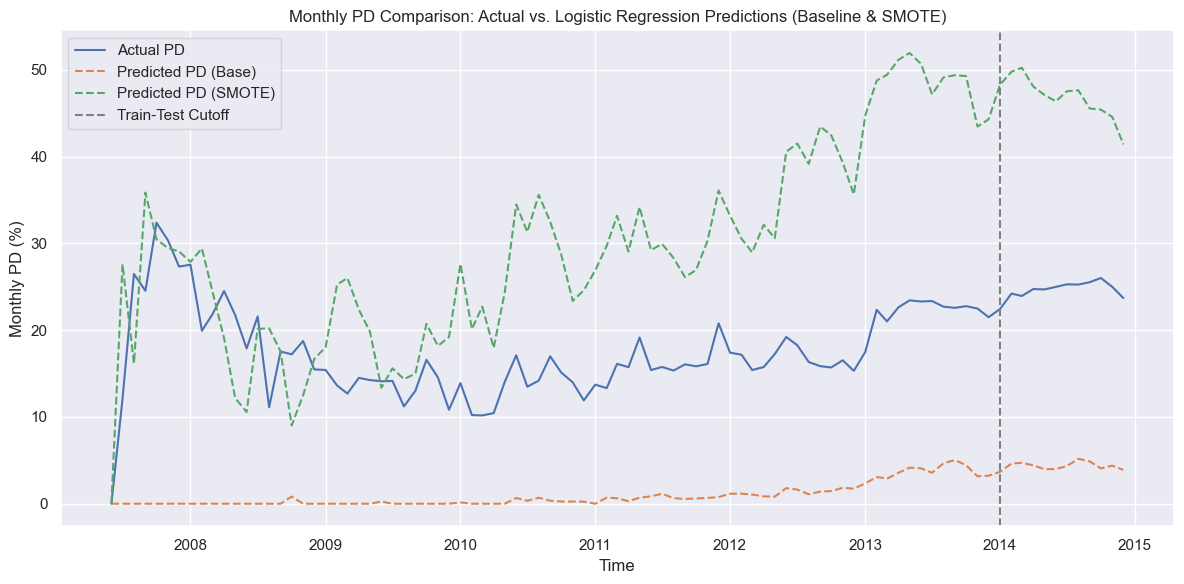

In [459]:
# Calculate monthly PDs for actual
actual_pd = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_true'].mean() * 100).reset_index()

# Calculate monthly PDs for predicted (both base and SMOTE)
pred_pd_base = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_pred_base'].mean() * 100).reset_index()
pred_pd_smote = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_pred_smote'].mean() * 100).reset_index()


# Convert Period to timestamp for plotting
actual_pd['issue_date'] = actual_pd['issue_date'].dt.to_timestamp()
pred_pd_base['issue_date'] = pred_pd_base['issue_date'].dt.to_timestamp()
pred_pd_smote['issue_date'] = pred_pd_smote['issue_date'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(actual_pd['issue_date'], actual_pd['default_true'], label='Actual PD')
plt.plot(pred_pd_base['issue_date'], pred_pd_base['default_pred_base'], label='Predicted PD (Base)', linestyle='--')
plt.plot(pred_pd_smote['issue_date'], pred_pd_smote['default_pred_smote'], label='Predicted PD (SMOTE)', linestyle='--')

# Add a vertical line for the train-test cutoff at '2014-01-01'
plt.axvline(pd.to_datetime('2014-01-01'), color='gray', linestyle='--', label='Train-Test Cutoff')

# Labeling
plt.xlabel('Time')
plt.ylabel('Monthly PD (%)')
plt.title('Monthly PD Comparison: Actual vs. Logistic Regression Predictions (Baseline & SMOTE)')
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust the layout
plt.show()

In [460]:
# Show the table of metrics on test data
print("Metrics on Test dataset:")
metrics_summary_df

Metrics on Test dataset:


,Model,Accuracy,Recall,Precision,F1 Score,AUC
0,Logistic Regression Baseline,0.7561,0.0943,0.5395,0.1605,0.6896
1,Logistic Regression SMOTE,0.6159,0.6775,0.3550,0.4659,0.6866


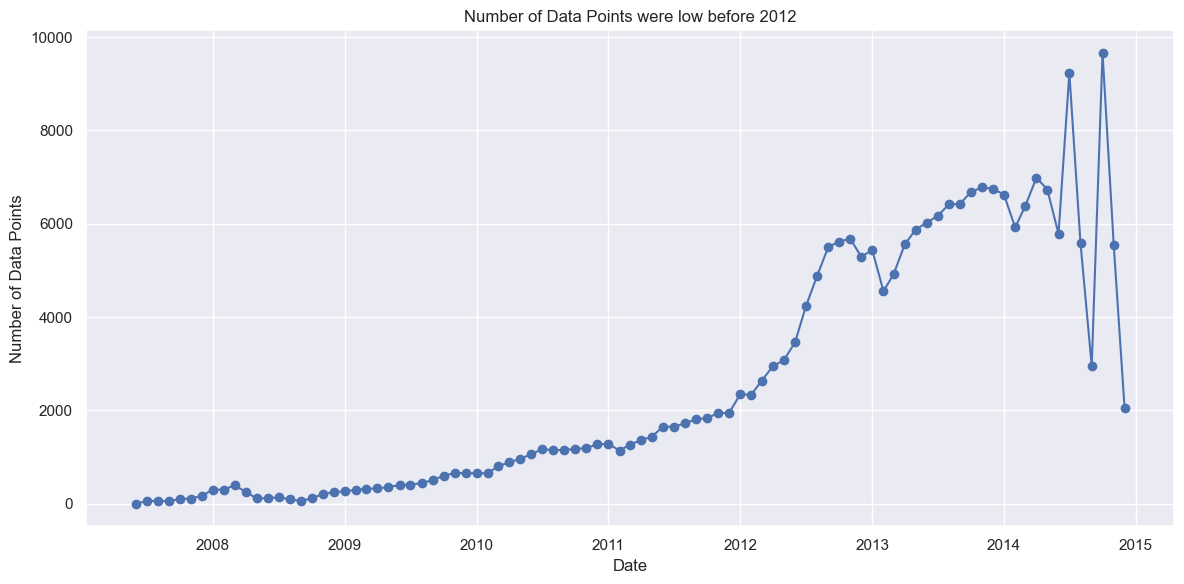

In [461]:
# Count the number of data points for each month
monthly_counts = full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M')).size().reset_index(name='count')

# Convert the Period to Timestamp for plotting
monthly_counts['issue_date'] = monthly_counts['issue_date'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts['issue_date'], monthly_counts['count'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Number of Data Points')
plt.title('Number of Data Points were low before 2012') 
plt.grid(True)
plt.tight_layout()  
plt.show()

- **Insights:**
 
1. **Baseline Model Performance**: The plot indicates that while the baseline model captures the recent upward trend in Probability of Default (PD), it fails to recognize movements in PD for most of the period. Class imbalance inhibits the model from effectively learning patterns associated with the default class.

2. **Logistic Regression with SMOTE Resampling**: This approach demonstrates better predictive performance for PD before 2010. Furthermore, the model effectively captures monthly PD dynamics across different years.

3. **Performance Over Time**: 
   - The baseline model exhibited significant deficiencies in predicting training data prior to 2013, showing little pattern recognition before 2012. 
   - In contrast, the model using SMOTE captures dynamics more effectively; however, it appears to amplify the magnitude of predictions. This amplification leads to increased divergence over time as the model's predictions move further from actual values.

4. **Overall Model Findings**: The baseline model tends to underestimate PD, while the SMOTE-enhanced model often overestimates PD. Both scenarios pose challenges for banks.
   - **As a Risk Management Officer**: Overestimating PD requires the bank to allocate excessive capital reserves for future credit risks, leading to inefficient use of capital. Conversely, underestimating PD creates the risk of inadequate capital coverage for potential future losses, a situation that may attract regulatory scrutiny.
   - **As a Business Unit for Loan Approval**: Overestimating PD can result in the loss of potential customers and revenue due to unjustly rejecting loans that are unlikely to default. Conversely, underestimating PD may result in higher-than-expected losses from approving loans that do default.

5. **AUC Score Consideration**: The effectiveness of performance metrics is guided by specific business objectives (e.g., capital efficiency vs. maximizing approvals). The AUC score is crucial in PD modeling as it measures the model's fundamental ability to differentiate between default and non-default loans, remaining independent of the selected risk threshold. Both models achieving an AUC score near 0.7 indicate a solid capacity for actionable ranking in risk-based decision-making.

6. **Future Steps**: Moving forward, I will select the training data from 2013 and the testing data from 2014. Additionally, I will apply SMOTE to help the model better learn the characteristics of the minority class.

---

## 8. Logistic Regression: Training on Data from the Most Recent Year & SMOTE <a class="anchor" id="8"></a>

### 8.1 Reselect data  <a class="anchor" id="8a"></a>

- Selecting 2013 data for train

In [462]:
# Check number of observations each yeat
pd_model_df['issue_year'].value_counts()

issue_year
2014    73459
2013    71575
2012    48027
2011    19067
2010    12157
2009     5265
2008     2381
2007      571
Name: count, dtype: int64

In [463]:
# Reselecting the training set (2013)
train_df_2013 = pd_model_df[(pd_model_df['issue_year'] == 2013)].copy()

# Check
print(f"Training set size: {len(train_df_2013 )}")
print(f"Testing set size: {len(test_df)}")

Training set size: 71575
Testing set size: 73459


In [464]:
# Define the list of columns to exclude
cols_to_drop = ['is_default', 'exposure_at_default', 'loss_given_default', 'loan_status'] 

# Create X_train
X_train_2013 = train_df_2013.drop(columns=cols_to_drop).copy()

# Create y
y_train_2013  = train_df_2013['is_default'].copy()

### 8.2 Train & Metrics  <a class="anchor" id="8b"></a>

- Fit Logistic Regression Again

In [465]:
# Define the preprocessing pipeline for ordinal columns
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder()),
    ('scaler', StandardScaler())
])

# Create a column transformer
preprocessor = ColumnTransformer(  
    transformers=[
        ('cat_cols', OneHotEncoder(sparse_output=False,
                                   handle_unknown='ignore',
                                   drop='first'), categorical_columns), 
        ('num_cols', StandardScaler(), numerical_columns),
        ('ord_cols', ordinal_pipeline, ordinal_columns)       
    ]
)



# Create the pipeline for grid search using logistic regression
pipeline_recent_smote = ImbPipeline(steps=[
    # Step 1: Preprocessing (OHE + Scaling)
    ('preprocessor', preprocessor), 
    
    # Step 2: Resampling 
    ('smote', SMOTE(sampling_strategy=0.65, random_state=42)), 
    
    # Step 3: Classification
    ('classifier', LogisticRegression())
])

In [466]:
# Fit the model
pipeline_recent_smote.fit(X_train_2013, y_train_2013)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose',
                                                   'initial_list_status',
                                                   'mths_since_delinq_category',
                                                   'state_group',
                                                   'derogatory_pub_rec']),
                                                 ('num_cols', StandardScaler(),
                                                  ['funded_amnt', 'int_rate',
                                                   'annual_inc', 'dti',
                                                   'delinq_2yrs',
                                                   'inq_last_6mths',
                                                   'revol_util', 'total_acc',
                                                   'issue_year', 'issue_month',
                                                   'is_revl_acct',
                                                   'is_term_60_mths']),
                                                 ('ord_cols',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['grade'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.65)),
                ('classifier', LogisticRegression())])

Evaluation: Logistic Regression Most Recent Year
Confusion matrices: 


<Figure size 300x300 with 0 Axes>

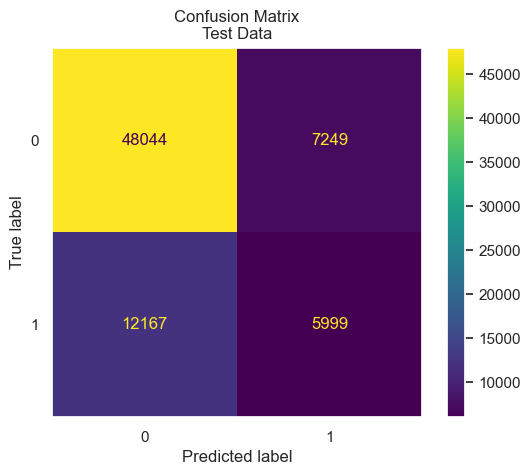

Test Data Classification Report: 
==================================================================               precision    recall  f1-score   support

           0       0.80      0.87      0.83     55293
           1       0.45      0.33      0.38     18166

    accuracy                           0.74     73459
   macro avg       0.63      0.60      0.61     73459
weighted avg       0.71      0.74      0.72     73459

Recall Score:
Train: 0.403
Test: 0.330 
False Positive Rate:
Train: 0.179
Test: 0.131 
AUC Score:
Train: 0.690
Test: 0.692 
Accuracy Score:
Train: 0.728
Test: 0.736 
Precision Score:
Train: 0.391
Test: 0.453 
F1 Score:
Train: 0.397
Test: 0.382 


In [467]:
# Use self-built ModelEvaluator to evaluate the mode
print("Evaluation: Logistic Regression Most Recent Year")
evaluator = ModelEvaluator(pipeline_recent_smote)
evaluator.evaluate(X_train_2013, X_test, y_train_2013, y_test)

ROC Curve: Logistic Regression SMOTE & Most Recent Data


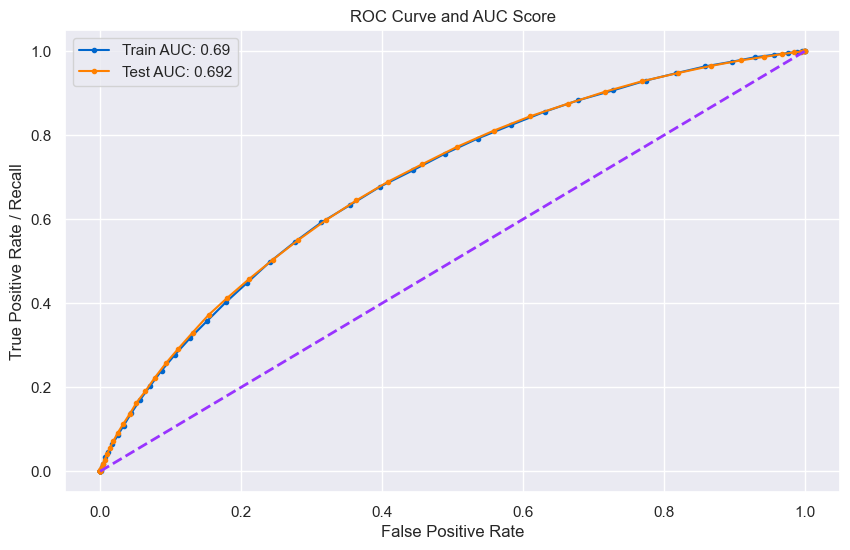

In [468]:
# Plot the roc curve 
print('======='*8)
print('ROC Curve: Logistic Regression SMOTE & Most Recent Data')
print('======='*8)
evaluator.plot_roc_auc_curve(X_train_2013, X_test, y_train_2013, y_test)

### 8.3 Model comparisons  <a class="anchor" id="8c"></a>


In [469]:
# Store the metrics of Logistic Regression 
metrics_summary_df = evaluate_model(pipeline_recent_smote, X_train_2013, y_train_2013, X_test, y_test, 'Logistic Regression Recent Year')
metrics_summary_df

,Model,Accuracy,Recall,Precision,F1 Score,AUC
0,Logistic Regression Baseline,0.7561,0.0943,0.5395,0.1605,0.6896
1,Logistic Regression SMOTE,0.6159,0.6775,0.3550,0.4659,0.6866
2,Logistic Regression Recent Year,0.7357,0.3302,0.4528,0.3819,0.6918


- Recreate the plot to compare performance

In [470]:
# Create DataFrames for storing results
X_train_results_recent = X_train_2013.copy()
X_test_results_recent = X_test.copy()

y_pred_train_3 = pipeline_recent_smote.predict(X_train_2013)
y_pred_test_3 = pipeline_recent_smote.predict(X_test)

X_train_results_recent['default_pred_recent'] = y_pred_train_3
X_test_results_recent['default_pred_recent'] = y_pred_test_3

# Combine two dfs for full resutls
full_results_2013_df = pd.concat([X_train_results_recent, X_test_results_recent], ignore_index=True)

In [471]:
# Apply the function
full_aresults_2013_df = create_issue_date(full_results_2013_df)

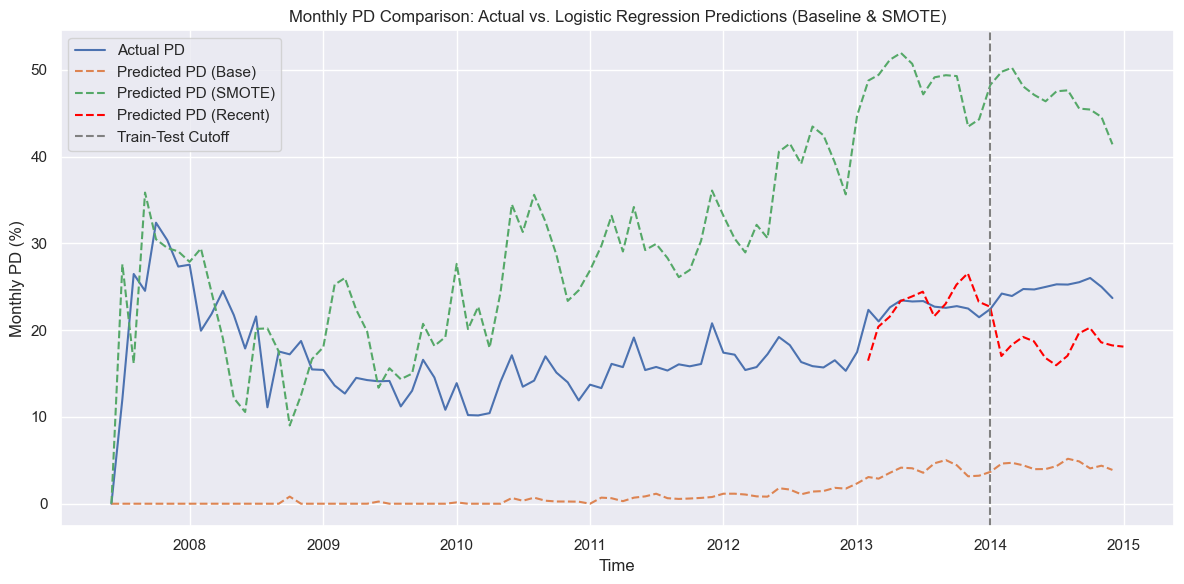

In [472]:
# Calculate monthly PDs for actual
actual_pd = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_true'].mean() * 100).reset_index()

# Calculate monthly PDs for predicted (both base and SMOTE)
pred_pd_base = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_pred_base'].mean() * 100).reset_index()
pred_pd_smote = (full_results_df.groupby(full_results_df['issue_date'].dt.to_period('M'))['default_pred_smote'].mean() * 100).reset_index()
pred_pd_recent = (full_results_2013_df.groupby(full_results_2013_df['issue_date'].dt.to_period('M'))['default_pred_recent'].mean() * 100).reset_index()

# Convert Period to timestamp for plotting
actual_pd['issue_date'] = actual_pd['issue_date'].dt.to_timestamp()
pred_pd_base['issue_date'] = pred_pd_base['issue_date'].dt.to_timestamp()
pred_pd_smote['issue_date'] = pred_pd_smote['issue_date'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(actual_pd['issue_date'], actual_pd['default_true'], label='Actual PD')
plt.plot(pred_pd_base['issue_date'], pred_pd_base['default_pred_base'], label='Predicted PD (Base)', linestyle='--')
plt.plot(pred_pd_smote['issue_date'], pred_pd_smote['default_pred_smote'], label='Predicted PD (SMOTE)', linestyle='--')
plt.plot(pred_pd_recent['issue_date'], pred_pd_recent['default_pred_recent'], label='Predicted PD (Recent)', linestyle='--', color='red')

# Add a vertical line for the train-test cutoff at '2014-01-01'
plt.axvline(pd.to_datetime('2014-01-01'), color='gray', linestyle='--', label='Train-Test Cutoff')

# Labeling
plt.xlabel('Time')
plt.ylabel('Monthly PD (%)')
plt.title('Monthly PD Comparison: Actual vs. Logistic Regression Predictions (Baseline & SMOTE)')
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust the layout
plt.show()

In [473]:
# Show metrics
metrics_summary_df

,Model,Accuracy,Recall,Precision,F1 Score,AUC
0,Logistic Regression Baseline,0.7561,0.0943,0.5395,0.1605,0.6896
1,Logistic Regression SMOTE,0.6159,0.6775,0.3550,0.4659,0.6866
2,Logistic Regression Recent Year,0.7357,0.3302,0.4528,0.3819,0.6918


- **Insights:**
 
1. **Enhanced PD Predictions**: The model demonstrates significantly improved performance in predicting Probability of Default (PD) compared to the previous two models, exhibiting the following characteristics:
   - It captures the dynamics of PD movements, although there are some gaps, and changes in predicted values may lag behind actual values.
   - In contrast to the second model, where the divergence between actual PD and predicted PD increased over time, training this model on the most recent data allows it to focus on current risk factors.

2. **Mitigation of Overfitting**: Overfitting appears to have been mitigated, as the accuracy scores for both the training and testing datasets are similar.

3. **Slight Advantage in AUC Score**: The model shows a minor improvement in AUC score, indicating slightly better discriminatory power compared to earlier models.

4. The results enhance some of the importance in PD modeling:
   - It is important to use recent data to help model capture the most updated risk characteristics.
   - Resampling is important for the model to learn the minority class, and it is even more important if the borrowers have lower default rate. We might need to switch to Bayes Model for extremely low PD.
   - Modeling using long-term data and near term data helps us understand the underlying issues and extract insights in finding the most appropriate technique.

5. As the goal for this project is not focused on modeling performance, and the model does not show signs of overfitting, I will skip grid search for finding the best set of hyperparameters.

---

### 8.4 Model interpretation  <a class="anchor" id="8d"></a>

In [481]:
# Extract the logistic regression model
logistic_model = pipeline_recent_smote.named_steps['classifier']

# Get the coefficients and intercept
coefficients = logistic_model.coef_[0]  # For binary classification, this will give you the coefficients
intercept = logistic_model.intercept_[0]  # Get the intercept term


In [482]:
# Get feature names from the OneHotEncoder
ohe = pipeline_recent_smote.named_steps['preprocessor']

# Obtain feature names after one-hot encoding
cat_feature_names = ohe.transformers_[0][1].get_feature_names_out(categorical_columns)
num_feature_names = ohe.transformers_[1][1].get_feature_names_out(numerical_columns)
ord_feature_names = ohe.transformers_[2][1].get_feature_names_out(ordinal_columns)

In [483]:
# Combine feature names
feature_names = np.concatenate([cat_feature_names, num_feature_names, ord_feature_names])

# Create DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Create a DataFrame for the intercept
intercept_df = pd.DataFrame({'Feature': ['Intercept'], 'Coefficient': [intercept]})

In [484]:
# Concatenate the intercept DataFrame with the coefficients DataFrame
coef_df = pd.concat([coef_df, intercept_df], ignore_index=True)

# Sort the df by coefficients for visiualization
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)
coef_df_sorted

,Feature,Coefficient
0,int_rate,0.6453
1,purpose_small_business,0.4850
2,state_group_State Group 5,0.4836
3,state_group_State Group 4,0.4694
4,state_group_State Group 6,0.4427
5,state_group_State Group 3,0.3251
6,purpose_home_improvement,0.2832
7,purpose_debt_consolidation,0.2385
8,dti,0.1901
9,purpose_other,0.1730


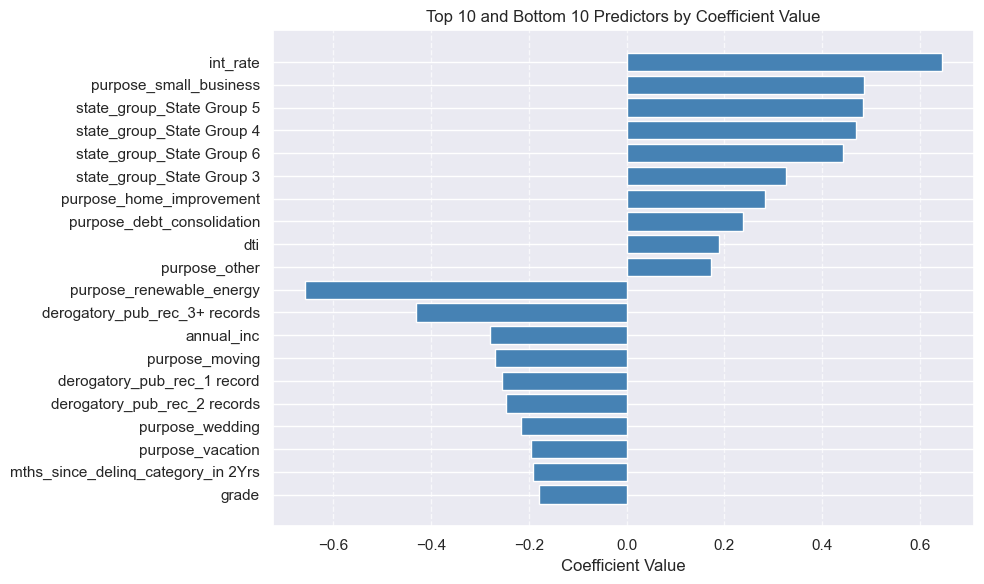

In [485]:
# Exclude the intercept from the DataFrame
coef_df_cleaned = coef_df_sorted[coef_df_sorted['Feature'] != 'Intercept']

# Select top 10 and bottom 10 features based on coefficient values
top_predictors = coef_df_cleaned.nlargest(10, 'Coefficient')
bottom_predictors = coef_df_cleaned.nsmallest(10, 'Coefficient')

# Combine the two DataFrames
combined_predictors = pd.concat([top_predictors, bottom_predictors])

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(combined_predictors['Feature'], combined_predictors['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Top 10 and Bottom 10 Predictors by Coefficient Value')
plt.gca().invert_yaxis()  # Invert y-axis to display the highest value on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()  # Adjust the layout for better fit
plt.show()

#### Coefficients interpretations


The Probability of Default ($\text{PD}$) is calculated using the sigmoid function:

$$\text{PD}(X) = \frac{1}{1 + e^{-f(X)}}$$

where $f(X)$ is the linear combination of features. The below table shows the strongest predictors from the model with either positive or negative impact on PD. I have also included a table of coefficient for of the parameters in the logistic regression for documentation. 

### Top 5 Features (Positive Coefficients)

| Parameter                             | Coefficient | Calculation     | Result | Interpretation                                                                                              |
|---------------------------------------|-------------|------------------|--------|--------------------------------------------------------------------------------------------------------------|
| **Interest Rate (β₁)**                | 0.6453      | $e^{0.6453}$     | 1.91   | Each unit increase in the interest rate increases the odds of default by a factor of 1.91.                  |
| **Purpose: Small Business (β₂)**      | 0.4850      | $e^{0.4850}$     | 1.62   | Choosing `Small Business` as the loan purpose increases the odds of default by a factor of 1.62.            |
| **State Group: State Group 5 (β₃)**  | 0.4836      | $e^{0.4836}$     | 1.62   | Belonging to `State Group 5` increases the odds of default by a factor of 1.62 compared to other groups.    |
| **State Group: State Group 4 (β₄)**  | 0.4694      | $e^{0.4694}$     | 1.60   | Belonging to `State Group 4` increases the odds of default by a factor of 1.60 compared to other groups.    |
| **State Group: State Group 6 (β₅)**  | 0.4427      | $e^{0.4427}$     | 1.56   | Belonging to `State Group 6` increases the odds of default by a factor of 1.56 compared to other groups.    |


### Bottom 5 Features (Negative Coefficients)

| Parameter                                           | Coefficient | Calculation       | Result | Interpretation                                                                                              |
|-----------------------------------------------------|-------------|--------------------|--------|--------------------------------------------------------------------------------------------------------------|
| **Purpose: Renewable Energy (β₁₀)**                   | -0.6575      | $e^{-0.6575}$      | 0.52   | Choosing `Renewable Energy` as the loan purpose decreases the odds of default to 52% compared to other purposes. |
| **Derogatory Public Records: 3+ Records (β₉)**      | -0.4300      | $e^{-0.4300}$      | 0.65   | Having 3 or more derogatory public records decreases the odds of default to 65% compared to having fewer records. |
| **Annual Income (β₈)**                               | -0.2789      | $e^{-0.2789}$      | 0.76   | Each unit increase in annual income decreases the odds of default to 76% compared to lower income levels.   |
| **Purpose: Moving (β₇)**                             | -0.2691      | $e^{-0.2691}$      | 0.76   | Choosing `Moving` as the loan purpose decreases the odds of default to 76% compared to other purposes.      |
| **Derogatory Public Records: 1 Record (β₆)**         | -0.2538      | $e^{-0.2538}$      | 0.78   | Having 1 derogatory public record decreases the odds of default to 78% compared to having none.             |

| State Group       | States                                                          |
|-------------------|-----------------------------------------------------------------|
| **State Group 1** | ME, ID, DC, WY                                                  |
| **State Group 2** | NH, CO, AK                                                     |
| **State Group 3** | WV, MT, CT, SC, KS, OR, TX, WA, IL, VT, UT, CA, MA           |
| **State Group 4** | WI, GA, AZ, SD, MN, VA, RI, MD, DE, PA, OH, NJ, MO, NC, MI, LA, NY, KY |
| **State Group 5** | AR, NM, OK, HI, IA, FL, AL, NV                                 |
| **State Group 6** | IN, TN, MS, NE                                                 |

- **Insights:**
1. The majority of the coefficients align with our findings from the exploratory data analysis (EDA). Specifically, the loan purpose of "small business" increases the odds of default, whereas loans for "renewable energy" purposes decrease the odds of default.

2. High interest rates also correlate with an increased likelihood of default, as elevated rates are often indicative of higher borrower credit risk. Additionally, borrowers may struggle to repay debts during stressful periods due to the burden of high-interest rates. It is important to note that interest rate data is only available for PD models predicting the default probability of existing loans; such information is not accessible to loan origination teams when assessing new applicants.

4. Borrowers in State Groups 4 and 5 are predicted to be more likely to default. This observation is consistent with our EDA findings, as these groups exhibit the higher PD rates.


## Logistic Regression Coefficients Summary

### Feature Coefficients

| Feature                                       | Coefficient |
|-----------------------------------------------|-------------|
| int_rate                                      | 0.6453      |
| purpose_small_business                        | 0.4850      |
| state_group_State Group 5                     | 0.4836      |
| state_group_State Group 4                     | 0.4694      |
| state_group_State Group 6                     | 0.4427      |
| state_group_State Group 3                     | 0.3251      |
| purpose_home_improvement                      | 0.2832      |
| purpose_debt_consolidation                   | 0.2385      |
| dti                                          | 0.1901      |
| purpose_other                                | 0.1730      |
| funded_amnt                                  | 0.1512      |
| home_ownership_RENT                          | 0.1349      |
| purpose_credit_card                          | 0.1172      |
| is_term_60_mths                             | 0.1103      |
| purpose_major_purchase                        | 0.0536      |
| revol_util                                   | 0.0485      |
| delinq_2yrs                                  | 0.0391      |
| purpose_medical                              | 0.0247      |
| issue_month                                   | 0.0193      |
| inq_last_6mths                               | 0.0170      |
| issue_year                                   | 0.0000      |
| is_revl_acct                                 | 0.0000      |
| verification_status_Source Verified            | -0.0420     |
| mths_since_delinq_category_in 1Yr              | -0.0424     |
| mths_since_delinq_category_More than 2Yrs      | -0.0758     |
| verification_status_Verified                  | -0.0786     |
| total_acc                                    | -0.1010     |
| home_ownership_OWN                           | -0.1101     |
| initial_list_status_w                         | -0.1389     |
| state_group_State Group 2                     | -0.1464     |
| purpose_house                                 | -0.1640     |
| grade                                         | -0.1785     |
| mths_since_delinq_category_in 2Yrs          | -0.1918     |
| purpose_vacation                              | -0.1952     |
| purpose_wedding                               | -0.2148     |
| derogatory_pub_rec_2 records                 | -0.2471     |
| derogatory_pub_rec_1 record                  | -0.2538     |
| purpose_moving                                | -0.2691     |
| annual_inc                                    | -0.2789     |
| derogatory_pub_rec_3+ records                | -0.4300     |
| purpose_renewable_energy                      | -0.6575     |
| Intercept                                     | -1.0640     |

### 8.5 Multicollinearity  <a class="anchor" id="8e"></a>

In [486]:
# Apply the preprocessor (OHE + Scaling) to the training features.
X_train_2013_processed = preprocessor.fit_transform(X_train)

In [487]:
# Get the feature names and create a df to store 
feature_names = preprocessor.get_feature_names_out()

# Store Preprocessed X_train
X_processed_df = pd.DataFrame(X_train_2013_processed, columns=feature_names)

In [488]:
# Calculate VIF for Each Feature 
# Note: A small constant (1e-10) is added to avoid division by zero if VIF is very high.
vif_data = pd.DataFrame()
vif_data["feature"] = X_processed_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_processed_df.values, i) 
    for i in range(len(X_processed_df.columns))
]

In [489]:
# Sort the results to see the highest collinearity first
vif_data = vif_data.sort_values(by='VIF', ascending=False)
vif_data.head(15)

,feature,VIF
6,cat_cols__purpose_debt_consolidation,25.8281
24,cat_cols__state_group_State Group 4,20.1387
23,cat_cols__state_group_State Group 3,19.1510
31,num_cols__int_rate,11.6103
42,ord_cols__grade,10.5235
5,cat_cols__purpose_credit_card,9.5648
25,cat_cols__state_group_State Group 5,6.4757
13,cat_cols__purpose_other,3.6587
8,cat_cols__purpose_home_improvement,3.5384
38,num_cols__issue_year,3.0540


1. The VIF scores for variables with score >10 are relatively high, indicating instability in the coefficients associated with these features. As a result, we cannot fully rely on the coefficient estimates from these variables. However, dropping these features may lead to a reduction in the richness of the model, as they contain critical information. The decision should weigh the trade-off between information retention and model stability, ultimately depending on specific business needs.

2. With access to larger datasets, we could further refine our Probability of Default (PD) analysis by developing separate PD models for each loan purpose. Alternatively, we could segment the loan purposes into similar characteristics, such as secured versus unsecured loans, term loans versus revolving loans, or mortgage versus revolving credit. The approach we take will depend on the business requirements and the volume of available data.


---

## 9. Summary <a class="anchor" id="9"></a>

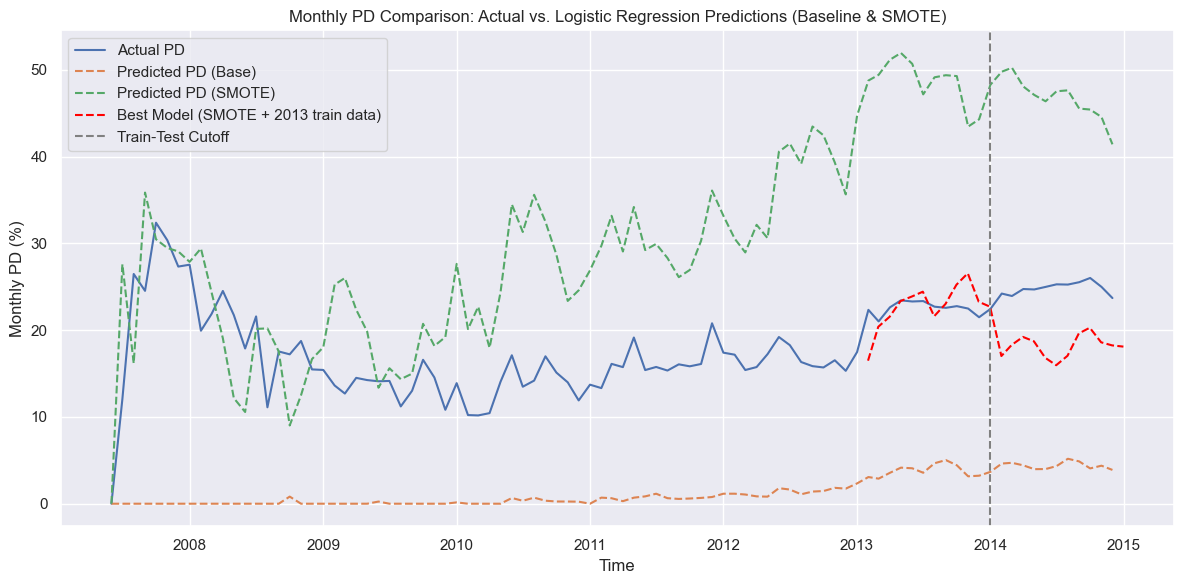

In [490]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(actual_pd['issue_date'], actual_pd['default_true'], label='Actual PD')
plt.plot(pred_pd_base['issue_date'], pred_pd_base['default_pred_base'], label='Predicted PD (Base)', linestyle='--')
plt.plot(pred_pd_smote['issue_date'], pred_pd_smote['default_pred_smote'], label='Predicted PD (SMOTE)', linestyle='--')
plt.plot(pred_pd_recent['issue_date'], pred_pd_recent['default_pred_recent'], label='Best Model (SMOTE + 2013 train data)', linestyle='--', color='red')

# Add a vertical line for the train-test cutoff at '2014-01-01'
plt.axvline(pd.to_datetime('2014-01-01'), color='gray', linestyle='--', label='Train-Test Cutoff')

# Labeling
plt.xlabel('Time')
plt.ylabel('Monthly PD (%)')
plt.title('Monthly PD Comparison: Actual vs. Logistic Regression Predictions (Baseline & SMOTE)')
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust the layout
plt.show()

#### Model Performance Metrics Summary


| Model                           | Accuracy | Recall  | Precision | F1 Score | AUC   |
|---------------------------------|----------|---------|-----------|----------|-------|
| Logistic Regression Baseline    | 0.7561   | 0.0943  | 0.5395    | 0.1605   | 0.6896|
| Logistic Regression SMOTE       | 0.6159   | 0.6775  | 0.3550    | 0.4659   | 0.6866|
| Logistic Regression Recent Year  | 0.7357   | 0.3302  | 0.4528    | 0.3819   | 0.6918|

1. By utilizing the most recent year of data for training and applying SMOTE for resampling the minority class (default borrowers), I have improved our model's performance.

2. The final model achieves an AUC score of 0.69, indicating a solid capacity for actionable ranking in risk-based decision-making.

3. While there remains a minor multicollinearity issue in our final model, which affects the stability of the coefficients for two categorical variables, the decision to retain or drop such features should consider their actual impact. There is a trade-off between information retention and model stability.

4. The model-building process reinforces the belief that PD is not static over time. Therefore, we should develop multiple models to predict both long-term PD and Point-in-Time PD. These predictions can provide insights into shifts in PD and changes in borrower attributes, enabling business users to adapt their decision-making processes accordingly.

5. Adding macroeconomic features is likely to enhance the model's ability to capture current economic factors, as these factors have historically correlated with PD, which can be a side project in the future.

In [387]:
# Export preprocessed data
loan_pp_df.to_csv('../data/loan_preprocessed.csv')

In [101]:
# Export the fitted pipeline to a file
joblib.dump(pipeline_recent_smote, '../model/logistic_regression_pipeline.pkl')

['../model/logistic_regression_pipeline.pkl']